In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

# Lotka-Volterra

In [2]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)
true_coeffs = generate_lotka_volterra_true_coefficients(1, 0.1, 1.5, 0.75)

dt = 0.01
noise_levels = np.logspace(-3, 0, 10).tolist()
t_spans = sorted([(0, 2*i) for i in range(1, 10 + 1)], reverse=True)

t_span_test = (0, 50)

# if a parameter is a list, the experiment will be run for each combination of the parameters
# if a parameter is not a list, the same value will be used for all experiments
# the first list will be the rows and the second list will be the columns
experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span_test[0], t_span_test[1] + 0.01, 0.01),
    # define parameters that can be lists
    'x0': (10, 5),
    'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dt, 't_span_train': t_spans,
    'threshold': 0.05,
    'poly_order': 5,
    'n_frequencies': 0,
    # define parameters that are used after the experiment
    'true_coeffs': true_coeffs
}

results = run_experiment(experiment_config)

rows are noise_level. there are 10 rows.
columns are t_span_train. there are 10 columns.
step 1 of 10


100%|██████████| 10/10 [00:07<00:00,  1.34it/s]


step 2 of 10


100%|██████████| 10/10 [00:07<00:00,  1.31it/s]


step 3 of 10


...

100%|██████████| 10/10 [00:10<00:00,  1.05s/it]


step 9 of 10


100%|██████████| 10/10 [00:07<00:00,  1.25it/s]


step 10 of 10


100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


rows are noise_level. there are 10 rows.
columns are t_span_train. there are 10 columns.


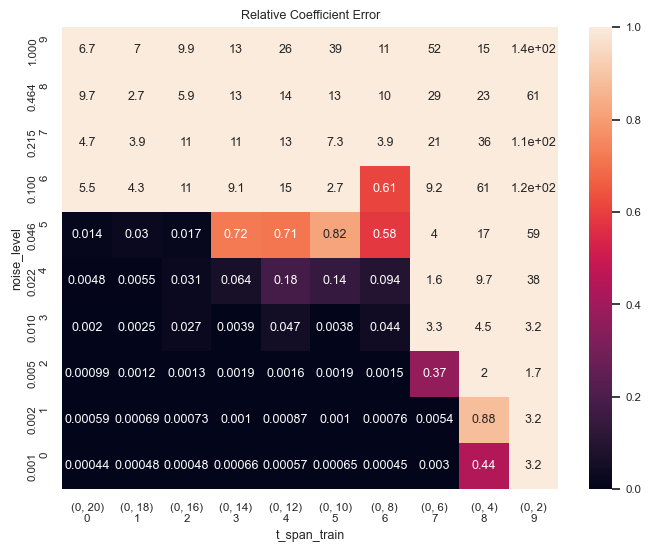

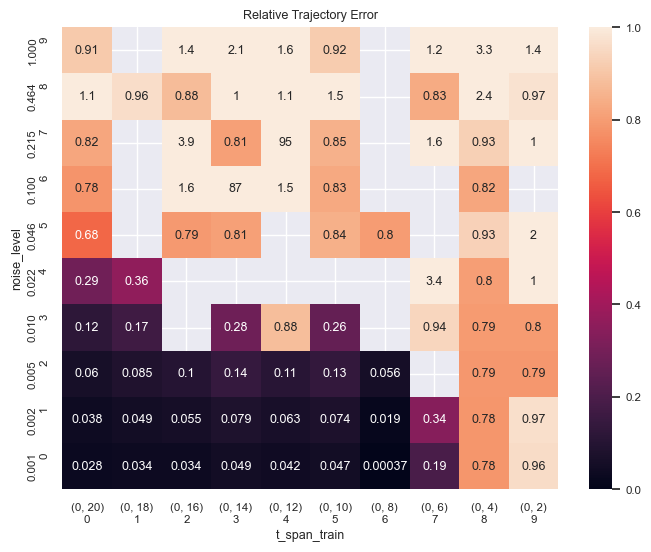

In [3]:
plot_heatmaps(experiment_config, results)

x0' = + 0.98944 x0 + -0.09975 x0 x1 
x1' = + -1.49978 x1 + 0.74987 x0 x1 


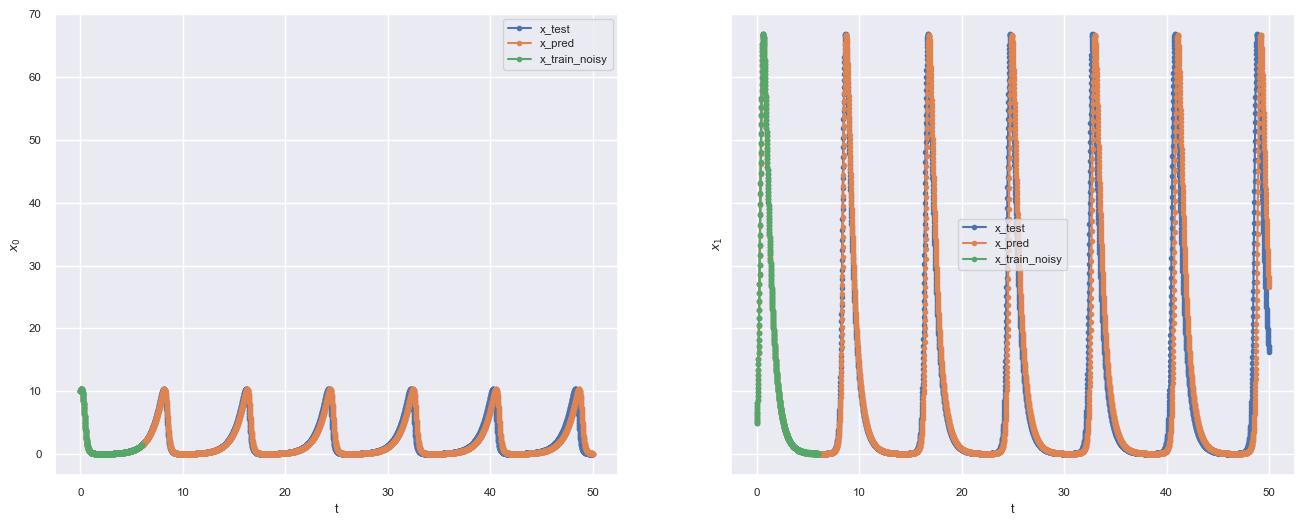

In [4]:
display_single_result(experiment_config, results, 7, 1, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])